# 02 - Table 3: So sánh Baselines (ĐA LỚP / Multiclass)

Huấn luyện RF, XGBoost, Vanilla MLP và **CyberDetect-MLP** trên artifacts đa lớp từ NB01.
Tầng output = `Dense(n_classes, softmax)`, loss = `sparse_categorical_crossentropy`,
metric macro (precision/recall/F1) + ROC-AUC OVR macro -- đúng chuẩn bài báo gốc.
Hyperparams Table 2: 100 epochs, batch 64, patience 10, cosine annealing, class_weight balanced.

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH (tránh lỗi Drive 'Transport endpoint is not connected') ===
# Làm việc trên Ổ CỨNG LOCAL /content (nhanh + ổn định); chỉ ĐỒNG BỘ kết quả về Drive ở cuối.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08 (cross-dataset can data/raw)
ON_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    for rel in ['scripts','src','models','results','data/colab_processed','data/ton_iot.csv']:
        try: _pull(rel)
        except Exception as e: print('  (bo qua)', rel, e)
    if NEED_RAW:
        print('  Dang keo data/raw (~550MB, 1-3 phut)...')
        try: _pull('data/raw')
        except Exception as e: print('  (bo qua) data/raw', e)

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)  # dam bao '!python ...' cung chay o local dir
except Exception:
    pass
for d in ('data/colab_processed','results','results/xai','models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv','data/raw/ton_iot.csv','ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive():
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for rel in ['data/colab_processed','models','results']:
        s = os.path.join(PROJECT_PATH, rel)
        if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
    print('[OK] Da dong bo ket qua ve Drive:', DRIVE)


Mounted at /content/drive
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
!pip -q install pandas numpy scikit-learn tensorflow xgboost pyarrow matplotlib seaborn


[START] Load artifacts da lop
[DONE] Load artifacts da lop - 0.2s
[INFO] X_train (168834, 30) | classes 10

[START] Random Forest
[DONE] Random Forest - 5.8s

[START] XGBoost
[DONE] XGBoost - 13.5s

[START] Train Vanilla MLP
Epoch 1/100
2111/2111 - 30s - 14ms/step - accuracy: 0.8012 - loss: 0.5131 - val_accuracy: 0.8188 - val_loss: 0.4283
Epoch 2/100
2111/2111 - 5s - 2ms/step - accuracy: 0.8473 - loss: 0.3904 - val_accuracy: 0.8610 - val_loss: 0.3679
Epoch 3/100
2111/2111 - 5s - 2ms/step - accuracy: 0.8679 - loss: 0.3441 - val_accuracy: 0.8764 - val_loss: 0.3325
Epoch 4/100
2111/2111 - 5s - 2ms/step - accuracy: 0.8747 - loss: 0.3224 - val_accuracy: 0.8732 - val_loss: 0.3265
Epoch 5/100
2111/2111 - 5s - 2ms/step - accuracy: 0.8772 - loss: 0.3148 - val_accuracy: 0.8745 - val_loss: 0.3174
Epoch 6/100
2111/2111 - 5s - 2ms/step - accuracy: 0.8781 - loss: 0.3111 - val_accuracy: 0.8738 - val_loss: 0.3177
Epoch 7/100
2111/2111 - 5s - 2ms/step - accuracy: 0.8792 - loss: 0.3066 - val_accuracy: 

[DONE] Train CyberDetect-MLP - 309.2s
 accuracy  precision   recall       f1  roc_auc           model  train_time_sec  epochs_ran
 0.989552   0.962141 0.977938 0.969089 0.999437   Random Forest        5.838426         NaN
 0.989031   0.960600 0.967547 0.963853 0.999783         XGBoost       13.469066         NaN
 0.916108   0.876872 0.842362 0.851311 0.992707     Vanilla MLP      334.927905        63.0
 0.874458   0.809219 0.863087 0.809409 0.988945 CyberDetect-MLP      308.954181        51.0


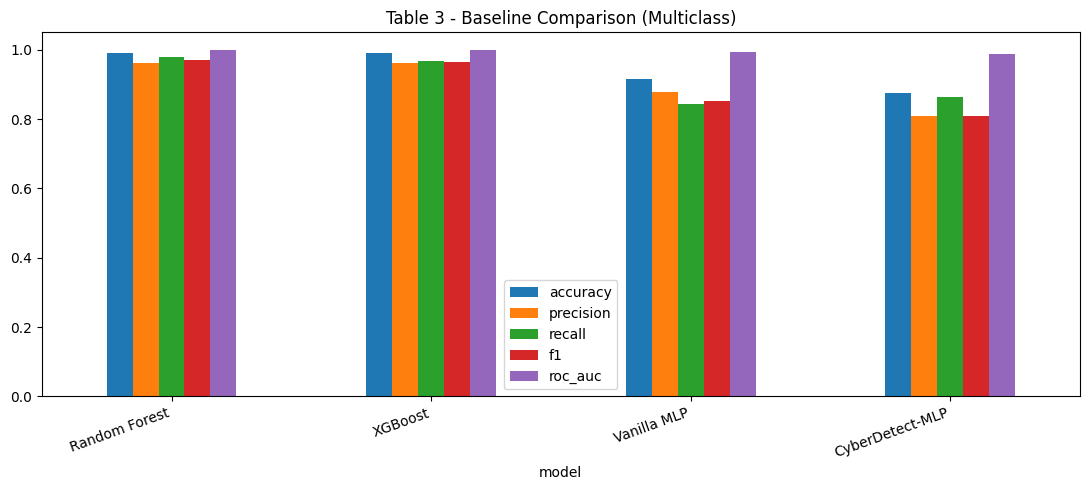

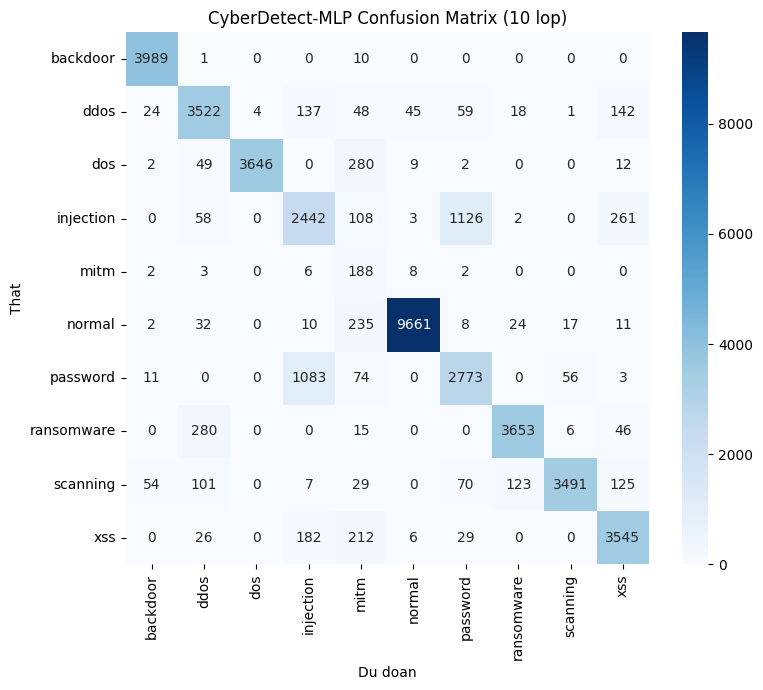

[OK] Da luu Table 3 da lop. LUU Y: accuracy da lop se THAP hon ban nhi phan -- day la ket qua trung thuc dung paper.


In [3]:
import os, json, time, math, random
import numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

OUT='data/colab_processed'; RESULTS='results'; MODELS='models'
os.makedirs(RESULTS, exist_ok=True); os.makedirs(MODELS, exist_ok=True)
meta = json.load(open(f'{MODELS}/colab_preprocessing_metadata.json', encoding='utf-8'))
N_CLASSES = meta['n_classes']; CLASS_NAMES = meta['class_names']
assert N_CLASSES > 2, 'Metadata khong phai da lop -- chay lai NB01 voi LABEL_COL=type'

with step('Load artifacts da lop'):
    X_train = pd.read_parquet(f'{OUT}/X_train_top30.parquet').values.astype('float32')
    X_test  = pd.read_parquet(f'{OUT}/X_test_top30.parquet').values.astype('float32')
    y_train = pd.read_parquet(f'{OUT}/y_train.parquet')['label'].values.astype(int)
    y_test  = pd.read_parquet(f'{OUT}/y_test.parquet')['label'].values.astype(int)
print('[INFO] X_train', X_train.shape, '| classes', N_CLASSES)

def set_seed(s=42): random.seed(s); np.random.seed(s); tf.random.set_seed(s)
def cosine(e, lr_min=1e-5, lr_max=1e-3, T=100): return lr_min + 0.5*(lr_max-lr_min)*(1+math.cos(math.pi*e/T))

def build_model(input_dim, n_classes, variant='full'):
    m = Sequential([Input(shape=(input_dim,))])
    for u in [512, 256, 128]:
        m.add(Dense(u, activation='relu'))
        if variant not in ('vanilla','no_batchnorm'): m.add(BatchNormalization())
        if variant not in ('vanilla','no_dropout'): m.add(Dropout(0.3))
    m.add(Dense(n_classes, activation='softmax'))
    m.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def macro_metrics(y, yp, prob):
    out = {'accuracy': accuracy_score(y, yp),
           'precision': precision_score(y, yp, average='macro', zero_division=0),
           'recall': recall_score(y, yp, average='macro', zero_division=0),
           'f1': f1_score(y, yp, average='macro', zero_division=0)}
    try: out['roc_auc'] = roc_auc_score(y, prob, multi_class='ovr', average='macro')
    except Exception: out['roc_auc'] = float('nan')
    return out

rows = []; preds = {}
with step('Random Forest'):
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    t=time.time(); rf.fit(X_train, y_train); yp=rf.predict(X_test); prob=rf.predict_proba(X_test)
    m=macro_metrics(y_test, yp, prob); m.update(model='Random Forest', train_time_sec=time.time()-t); rows.append(m); preds['Random Forest']=yp
if XGBClassifier is not None:
    with step('XGBoost'):
        xgb=XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1)
        t=time.time(); xgb.fit(X_train, y_train); yp=xgb.predict(X_test); prob=xgb.predict_proba(X_test)
        m=macro_metrics(y_test, yp, prob); m.update(model='XGBoost', train_time_sec=time.time()-t); rows.append(m); preds['XGBoost']=yp

for name, variant, cw in [('Vanilla MLP','vanilla',False), ('CyberDetect-MLP','full',True)]:
    with step(f'Train {name}'):
        set_seed(42); model=build_model(X_train.shape[1], N_CLASSES, variant)
        cbs=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
        if variant!='vanilla': cbs.append(LearningRateScheduler(lambda e: cosine(e, T=100)))
        class_weight=None
        if cw:
            w=compute_class_weight('balanced', classes=np.unique(y_train), y=y_train); class_weight=dict(enumerate(w))
        t=time.time(); hist=model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=64,
                                      callbacks=cbs, class_weight=class_weight, verbose=2)
        prob=model.predict(X_test, verbose=0); yp=prob.argmax(1)
        m=macro_metrics(y_test, yp, prob); m.update(model=name, train_time_sec=time.time()-t, epochs_ran=len(hist.history['loss']))
        rows.append(m); preds[name]=yp
        if name=='CyberDetect-MLP': model.save(f'{MODELS}/colab_cyberdetect_mlp.h5')

res=pd.DataFrame(rows); res.to_csv(f'{RESULTS}/colab_table3_metrics.csv', index=False); print(res.to_string(index=False))
cm=confusion_matrix(y_test, preds['CyberDetect-MLP'])
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(f'{RESULTS}/colab_confusion_matrix.csv')
open(f'{RESULTS}/colab_classification_report.txt','w',encoding='utf-8').write(
    classification_report(y_test, preds['CyberDetect-MLP'], target_names=CLASS_NAMES, zero_division=0))

res.set_index('model')[['accuracy','precision','recall','f1','roc_auc']].plot(kind='bar', figsize=(11,5))
plt.ylim(0,1.05); plt.title('Table 3 - Baseline Comparison (Multiclass)'); plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_colab_table3_comparison.png', dpi=150); plt.show()
plt.figure(figsize=(8,7)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('CyberDetect-MLP Confusion Matrix (10 lop)'); plt.ylabel('That'); plt.xlabel('Du doan'); plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_colab_confusion_matrix.png', dpi=150); plt.show()
print('[OK] Da luu Table 3 da lop. LUU Y: accuracy da lop se THAP hon ban nhi phan -- day la ket qua trung thuc dung paper.')

In [5]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
